In [1]:
import sys
import scipy.stats
# Change path to location of TensionMap directory
sys.path.append('../../TensionMap')
from src.segment import Segmenter
from src.VMSI import *
import numpy as np
import matplotlib.pyplot as plt
import skimage
import pandas as pd
import tifffile

In [8]:
mask = skimage.io.imread(f'../../ovarian/mask.tif')#[25000:35000, 25000:35000]

In [ ]:
#mask[13500:19500,4100:8100]

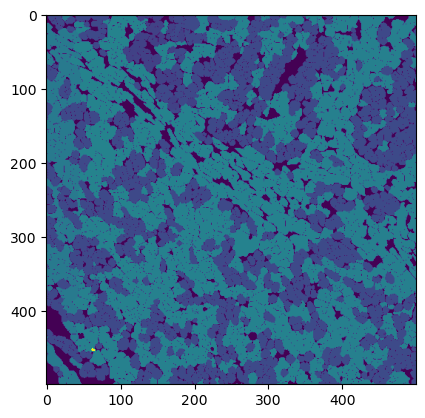

In [10]:
plt.imshow(mask)

In [9]:
#mask = mask[2700:2900,9000:9300]
mask = mask[2600:3100,4450:4950]
            #[2200:2500,4700:5000]#[14000:20000,45000:50000]#[1400:2000,4500:5000]#[13500:19500,4100:8100]

In [ ]:
from skimage import segmentation
mask = segmentation.clear_border(mask)

In [11]:
import numpy as np
from skimage.segmentation import expand_labels
from scipy.ndimage import distance_transform_edt

def assign_to_closest_with_max_distance(label_image, max_distance=2):
    """
    Assign unlabeled pixels (0) to closest labeled object,
    but only if within max_distance pixels.
    Uses expand_labels (simpler and more reliable).
    """
    # Step 1: Expand labels by max_distance pixels
    expanded = expand_labels(label_image, distance=max_distance)
    
    # Step 2: Calculate distance from unlabeled pixels to nearest labeled pixel
    distance = distance_transform_edt(label_image == 0)
    
    # Step 3: Only keep expanded pixels that are within max_distance
    valid_expansion = (label_image == 0) & (distance <= max_distance)
    
    # Step 4: Combine original + valid expanded
    filled = label_image.copy()
    filled[valid_expansion] = expanded[valid_expansion]
    
    return filled

In [ ]:
from skimage import morphology
mask = morphology.remove_small_objects(mask, min_size=10)
plt.imshow(mask)

In [ ]:
from skimage import measure
from skimage.morphology import binary_dilation, disk

def keep_touching_objects(label_image):
    labels = np.unique(label_image)
    labels = labels[labels != 0]

    out = np.zeros_like(label_image)

    for lab in labels:
        obj = label_image == lab
        touches_other = ~obj & (label_image > 0)

        if touches_other.any():
            out[obj] = lab

    return out

In [ ]:
from scipy.ndimage import distance_transform_edt, binary_dilation

def fill_small_gaps(mask, max_gap=3):
    height, width = mask.shape
    
    all_objects = mask > 0
    dilated = binary_dilation(all_objects, iterations=max_gap)
    
    gap_region = dilated & (mask == 0)
    
    print("Gap pixels found:", gap_region.sum())
    
    if not gap_region.any():
        print("No gap region to fill.")
        return mask
    
    obj_ids = np.unique(mask)
    obj_ids = obj_ids[obj_ids != 0]
    print("Object IDs:", obj_ids)
    
    if len(obj_ids) == 0:
        print("No objects in mask.")
        return mask
    
    min_dist = np.full((height, width), np.inf)
    nearest = np.zeros((height, width), dtype=mask.dtype)
    
    for obj_id in obj_ids:
        obj_mask = mask == obj_id
        dist = distance_transform_edt(~obj_mask)
        closer = (dist < min_dist) & gap_region
        if closer.any():
            min_dist[closer] = dist[closer]
            nearest[closer] = obj_id
    
    mask_filled = mask.copy()
    assigned = gap_region & (nearest > 0)
    print("Pixels assigned to objects:", assigned.sum())
    
    mask_filled[assigned] = nearest[assigned]
    
    print("Background before:", (mask == 0).sum())
    print("Background after:", (mask_filled == 0).sum())
    
    return mask_filled


In [ ]:
mask = fill_small_gaps(mask)

In [12]:
mask = assign_to_closest_with_max_distance(mask)

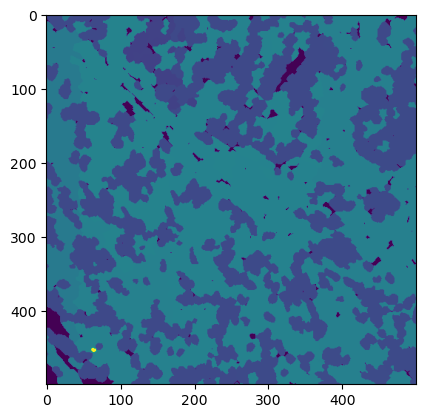

In [13]:
plt.imshow(mask)

In [ ]:
mask = keep_only_touching_objects(mask)

In [ ]:
plt.imshow(mask)

In [ ]:
mask = mask[8400:9000,900:1500]#[8600:9000,900:1300]

In [ ]:
tifffile.imwrite('mask_tiny.tif', mask)

In [ ]:
mask.shape

In [14]:
holes_mask = np.zeros_like(mask)
holes_mask = np.where(mask == 0, 1, 0).astype(bool)
mask = mask.astype(int)
mask = skimage.segmentation.find_boundaries(mask, mode='subpixel')

mask.shape

(999, 999)

In [ ]:
plt.imshow(holes_mask)

mask.shape

In [ ]:
np.unique(holes_mask)

In [15]:
from skimage import transform

scale1 = mask.shape[0] / holes_mask.shape[0]
scale2 = mask.shape[1] / holes_mask.shape[1]

holes_mask = transform.rescale(
    holes_mask, 
    scale=(scale1,scale2),
    anti_aliasing=False)


holes_mask = np.round(holes_mask).astype(int)

In [ ]:
holes_mask.shape

In [16]:
mask = 1-mask
mask = skimage.measure.label(mask)

In [ ]:
plt.imshow(mask)

In [ ]:
plt.imshow(mask*(1 - holes_mask))

In [ ]:
mask = (mask*(1 - holes_mask))

In [ ]:
# Detect holes
# holes are defined as tissue regions with area greater than 2x the mean cell area
holes_mask = np.zeros_like(mask)
areas = pd.DataFrame(skimage.measure.regionprops_table(label_image=mask, properties=('label','area')))
thresh = np.mean(areas['area'].tolist())*3
for area in areas.iterrows():
    if area[1]['area'] > thresh:
        holes_mask[mask==area[1]['label']] = 1

In [ ]:
areas['area'].mean()

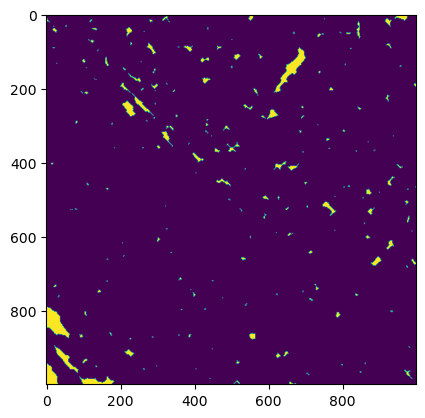

In [17]:
plt.imshow(holes_mask)

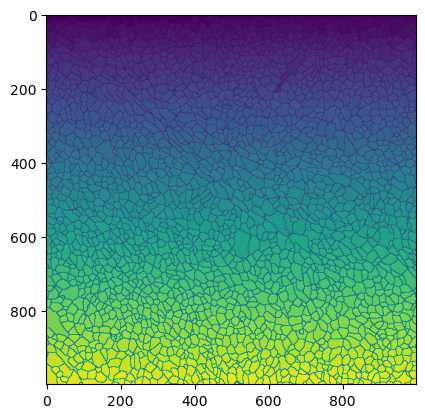

In [18]:
plt.imshow(mask)

In [ ]:
mask.shape

In [ ]:
import pickle

with open('masks_tiny.pickle', 'wb') as handle:
    pickle.dump({'mask': mask, 'holes_mask': holes_mask, 'areas': areas, 'thresh':thresh }, 
                handle, protocol=pickle.HIGHEST_PROTOCOL)

In [ ]:
import pickle

with open('masks_10x.pickle', 'wb') as handle:
    pickle.dump({'mask': mask, 'holes_mask': holes_mask}, 
                handle, protocol=pickle.HIGHEST_PROTOCOL)

In [ ]:
import pickle
with open('masks_10x.pickle', 'rb') as handle:
    unserialized_data = pickle.load(handle)
    mask = unserialized_data['mask']
    holes_mask = unserialized_data['holes_mask']

In [ ]:
selected_mask = np.zeros_like(mask)
for label in [119,129,137,138]:
    selected_mask[mask == label] = label

plt.imshow(selected_mask)

In [19]:
model = run_VMSI(mask, is_labelled=True, holes_mask=holes_mask, tile=False, verbose=False, optimiser='nlopt')

(999, 999) [   0    1    2 ... 1441 1442 1443]
1443 (1443,) (1443, 2)
[ 69. 121. 127. 136.] [0 1 0 1] [1 0 1 0] [ 56 104 117 181] [384 388 405 417] [53.30609697274039, 349.39535382036746]
[ 165.  179.  203. 2966.] [0 0 1 1] [1 1 0 0] [151 152 185 193] [868 895 930] [73.2894234484334, 675.4077181226005]
[ 180. 2965.  209.  212. 2968.] [1 1 0 0] [0 0 1 1] [154 174 185 194] [868 930 934 940] [78.58634145460353, 679.2808675983813]


IndexError: boolean index did not match indexed array along dimension 0; dimension is 5 but corresponding boolean dimension is 4

In [ ]:
model.__dict__['cells'].keys()

In [ ]:
list(model.__dict__['cells']['pressure'])

In [ ]:
model.plot(['pressure'], mask, size=100)